## 분류 모델 복습 + 평가지표 
###  Breast Cancer (유방암 진단) 데이터로 배우는 KNN · DT · RF
> 세포 측정값 30개로 **악성(Malignant)** vs **양성(Benign)** 판단 — 569개의 데이터       
> **정확도 accuracy_score( )  하나로 모델을 평가하는 것은 위험**     
> 특히 의료·금융·보안처럼 **놓치면 치명적인 케이스**가 있는 분야에서는 더욱 그렇습니다!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [3]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

In [4]:
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

## PART 1. 데이터 탐색 (EDA)

### load_breast_cancer() 데이터셋

| 항목 | 내용 |
|------|------|
| 샘플 수 | 569개 |
| 특성 수 | 30개 (세포측정값 — 반지름, 질감, 둘레 등등) |
| 클래스 | 0 = 악성(Malignant, 암) / 1 = 양성(Benign, 정상) |
| 출처 | UCI Machine Learning Repository |


In [5]:
from sklearn.datasets import load_breast_cancer

In [6]:
cancer = load_breast_cancer()
cancer

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [7]:
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [8]:
cancer['data']

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30))

In [9]:
cancer['target']

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [10]:
df = pd.DataFrame(cancer['data'],  columns= cancer['feature_names'] )
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [11]:
df['target'] = cancer['target']

In [12]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [13]:
cancer['target_names']

array(['malignant', 'benign'], dtype='<U9')

In [14]:
df['target_names'] = df['target'].map({0:'암',1:'양성'})

In [15]:
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_names
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0,암
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0,암
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0,암
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0,암
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0,암
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0,암
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0,암
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0,암
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0,암


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [17]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


<Axes: ylabel='count'>

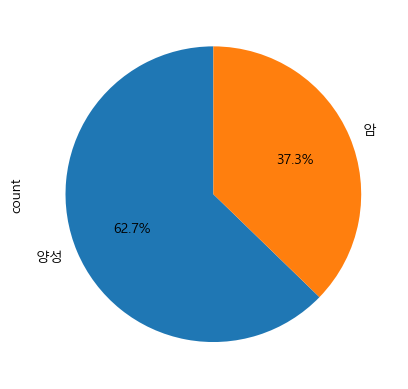

In [18]:
df['target_names'].value_counts().plot(kind='pie',autopct='%1.1f%%', startangle=90)

In [19]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target', 'target_names'],
      dtype='object')

<Axes: xlabel='mean radius', ylabel='Count'>

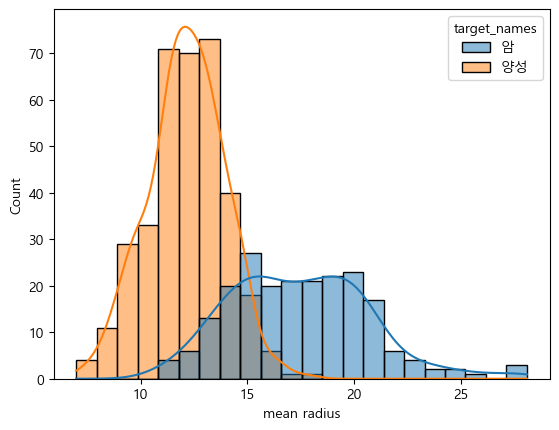

In [20]:
sns.histplot(data=df, x='mean radius', hue='target_names', kde=True)

In [21]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target', 'target_names'],
      dtype='object')

In [22]:
features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness']

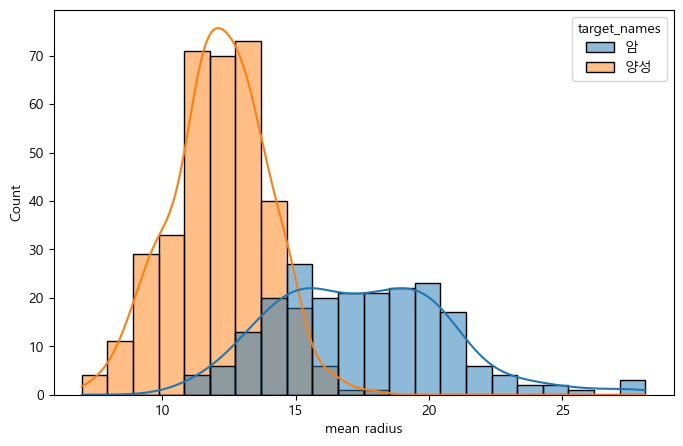

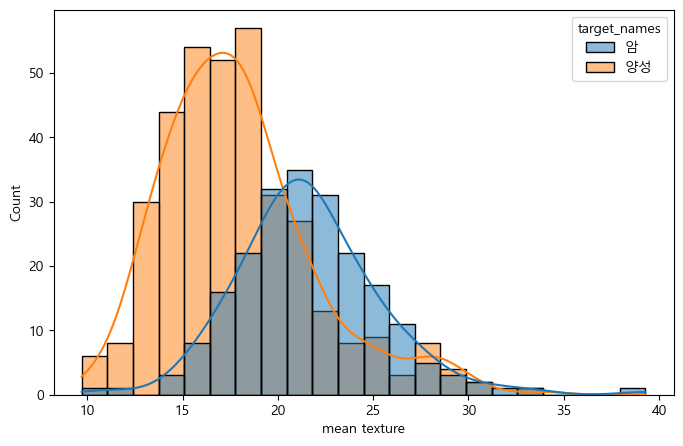

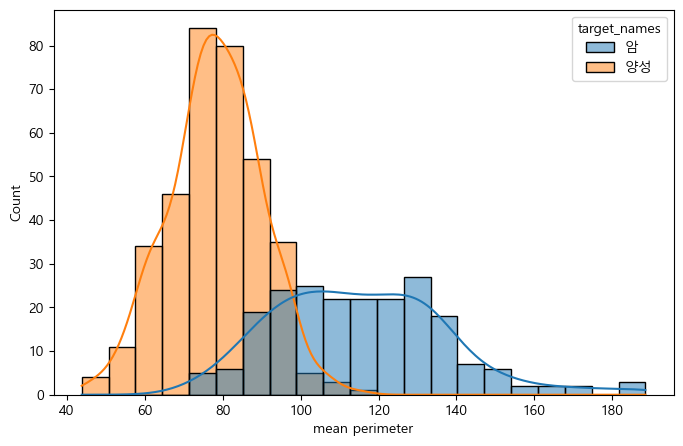

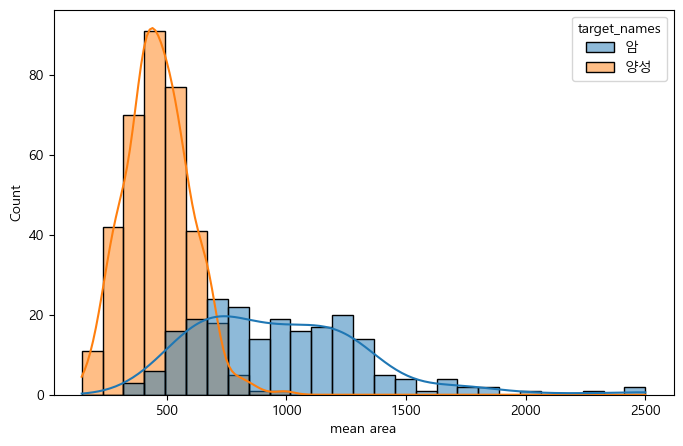

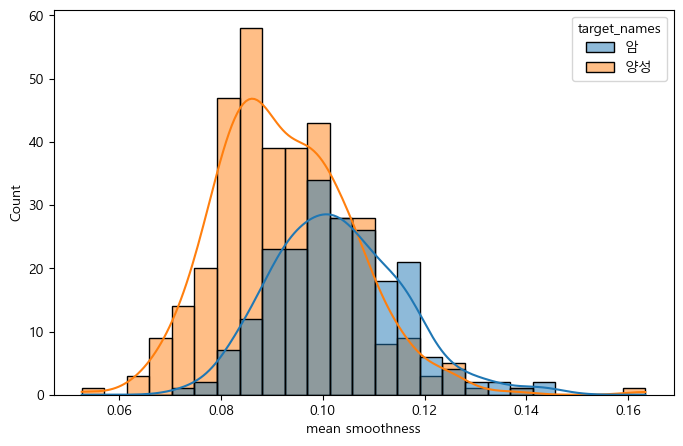

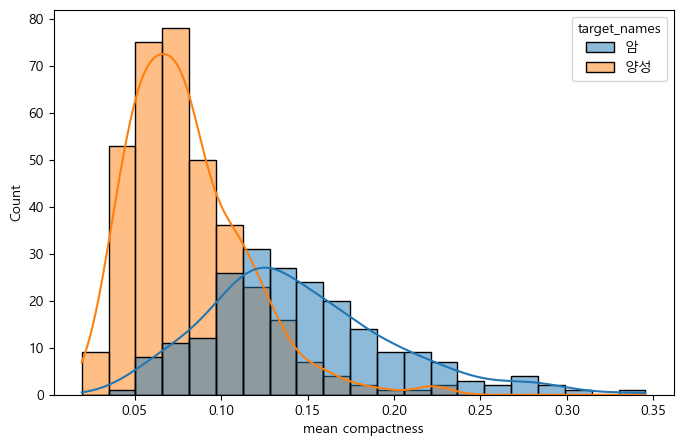

In [23]:
for   feature     in   features       :
    plt.figure(figsize=(8,5))
    sns.histplot(data=df, x=feature , hue='target_names', kde=True)

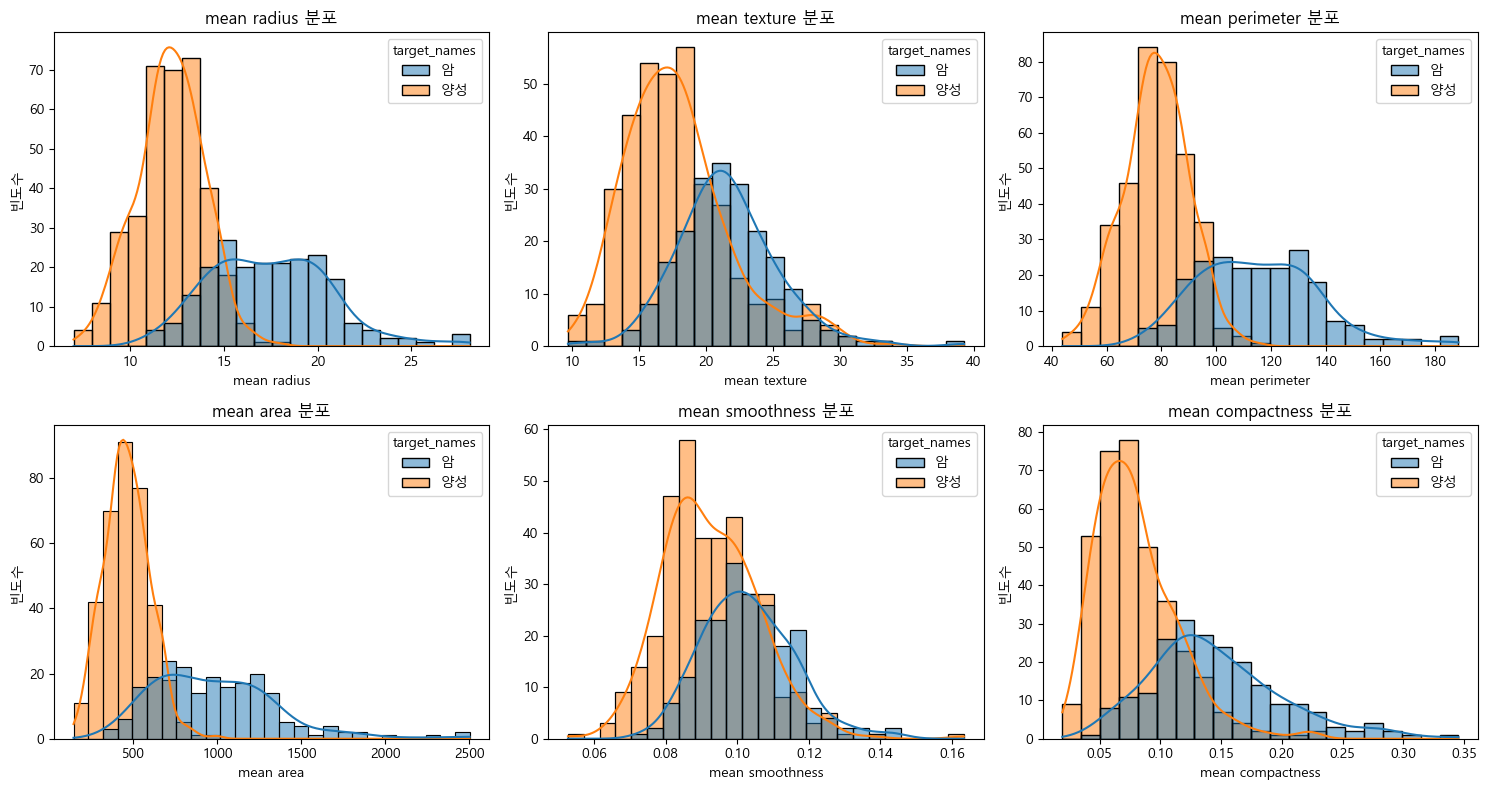

In [24]:
fig, axes = plt.subplots(2,3, figsize=(15,8))
axes = axes.flatten()
for i, feature in enumerate(features):
    sns.histplot(
        data=df,
        x=feature,
        hue='target_names',
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f'{feature} 분포')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('빈도수')
    
plt.tight_layout()
plt.show()

코드 이해   
``` python
fig, ax= plt.subplots(2, 3)
ax[0, 0]
ax[0, 1]
ax[0, 2]
ax[1, 0]
ax[1, 1]
ax[1, 2]
```

``` python
fig, ax= plt.subplots(2, 3)
ax = ax.flatten()  
ax[0]
ax[1]
ax[2]
ax[3]
ax[4]
ax[5]

## PART 2. 학습 모델 복습 — KNN · 결정트리 · 랜덤포레스트


| 모델 | 핵심 아이디어 | 스케일링 필요? |
|------|-------------|--------------|
| **KNN** | 가까운 k개 이웃의 **다수결** | 필수 (거리 계산) |
| **결정 트리** | YES/NO 질문의 **나무 구조** |  불필요 |
| **랜덤 포레스트** | 여러 트리의 **다수결 투표** | 불필요 |

> **공통 패턴**: `fit(X_train, y_train)` → `predict(X_test)`  중요!! 항상 같습니다!


In [25]:
df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target', 'target_names'],
      dtype='object')

In [26]:
X = df.drop(columns=['target', 'target_names'])
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [27]:
y = df['target_names']
y

0       암
1       암
2       암
3       암
4       암
       ..
564     암
565     암
566     암
567     암
568    양성
Name: target_names, Length: 569, dtype: object

In [28]:
X_train, X_test, y_train, y_test = train_test_split( X, y,
            train_size=0.8,
            random_state=0,
            stratify=y
) #stratify=y는 train_test_split()에서 암/양성 비율을 유지하면서 데이터를 나누는 옵션, 분류에서 사용

### 2-1. KNN — K-Nearest Neighbors (K 최근접 이웃)

```
새로운 환자의 세포 측정값
    ↓
30차원 공간에서 가장 가까운 K명의 환자를 찾음
    ↓
K명 중 암이 더 많으면 → 암 예측
K명 중 양성이 더 많으면 → 양성 예측
```

**KNN은 Scaler 필요!**
특성 30개의 단위/범위가 달라서, 스케일이 큰 특성이 거리를 지배합니다.
> **표준화 (StandardScaler)** : 평균 0, 표준편차 1이 되도록 변환    
> **정규화 (MinMaxScaler)**  : 모든 값을 0~1 사이로 변환

In [29]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [30]:
df.describe()
from sklearn.preprocessing import StandardScaler

scaler =  StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)       # 훈련 데이터를 기준으로 평균과 표준편차를 계산해 스케일링
X_test_scaled = scaler.transform(X_test)             # 테스트 데이터는 훈련 기준에 따라만 변환

- 주의: 만약 X_test에 대해 따로 fit()을 해버리면 훈련과 테스트의 변환 기준이 달라져 일관성 없는 평가가 됨

In [31]:
knn = KNeighborsClassifier()

In [32]:
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [33]:
y_pred = knn.predict(X_test_scaled)

In [34]:
accuracy_score(y_test, y_pred)

0.956140350877193

In [35]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

In [36]:
confusion_matrix(y_test, y_pred)

array([[38,  4],
       [ 1, 71]])

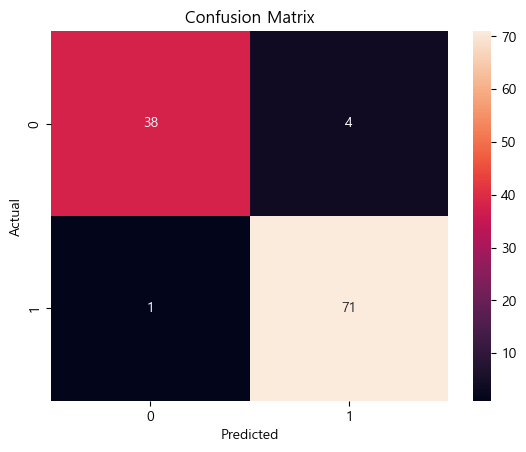

In [37]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

| 약자 | 이름 | 의미 | 유방암 진단에서 |
|------|------|------|--------------|
| **TP** | True Positive (진양성) | 실제 암 → 암으로 예측  | 정확히 암 환자 탐지 |
| **TN** | True Negative (진음성) | 실제 정상 → 정상으로 예측  | 정확히 정상 판정 |
| **FP** | False Positive (위양성) | 실제 정상 → 암으로 예측  | 불필요한 추가 검사 |
| **FN** | False Negative (위음성) | 실제 암 → 정상으로 예측  | **가장 위험! 치료 기회 놓침** |

> ** 유방암 데이터에서 "양성 클래스(Positive)"는 암 (0)입니다! **
> 즉, 우리가 탐지하려는 대상 = 암 = 0

## PART 3. 평가 지표 

### 3-1. Accuracy (정확도)

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

- **전체 예측 중 맞춘 비율**
- 클래스가 균형 잡혀 있을 때 유용
- 불균형 데이터(예: 전체 환자 100명 중  →  암 환자 5명 / 정상 95명) 에서 오해의 소지 있음 


### 3-2. Precision (정밀도) — "예측한 것 중 진짜는?"

$$\text{Precision} = \frac{TP}{TP + FP}$$

```
"암이라고 예측한 환자들 중에서, 실제로 암인 비율"

예시: Precision = 0.90
→ "암이라고 했을 때 90%는 진짜 암, 10%는 억울한 정상인"
```

**Precision이 중요한 상황**: 스팸 필터
- FP (정상 메일 → 스팸함) 가 많으면 중요한 메일을 놓침
- Precision 높이기 = FP 줄이기



### 3-3. Recall (재현율, 민감도) — "실제 환자 중 잡아낸 비율"

$$\text{Recall} = \frac{TP}{TP + FN}$$

```
"실제 암 환자 중에서, 암으로 예측된 비율"

예시: Recall = 0.95
→ "실제 암 환자 100명 중 95명을 잡아냄, 5명은 놓침"
```

**Recall이 중요한 상황**: 의료 진단
- FN (암 환자 → 정상 판정) 이 가장 위험
- Recall 높이기 = FN 줄이기



### 3-4. F1-score — Precision과 Recall의 균형

$$\text{F1} = \frac{2 \times Precision \times Recall}{Precision + Recall}$$

```
Precision = 1.0, Recall = 0.01  →  F1 = 0.020  (낮음)
Precision = 0.8, Recall = 0.8   →  F1 = 0.800  (높음)
```

- 단순 평균이 아닌 **조화 평균** → 두 지표 중 낮은 것에 더 민감
- 한 쪽만 높아서는 높은 F1 불가능
- 두 지표 모두 중요할 때 사용

### 지표 선택 가이드

| 상황 | 우선 지표 | 이유 |
|------|----------|------|
| 의료 진단 (암, 폐렴) | **Recall** | FN이 치명적 |
| 스팸 필터 | **Precision** | FP가 중요 메일 유실 |
| 사기 탐지 | **Recall** | 사기를 놓치면 안 됨 |
| 추천 시스템 | **Precision** | 엉뚱한 추천은 신뢰 하락 |
| 일반적 균형 | **F1-score** | 두 지표 동시 고려 |


In [38]:
precision_score(y_test, y_pred, pos_label='암')

0.9743589743589743

In [39]:
recall_score(y_test, y_pred, pos_label='암')

0.9047619047619048

In [40]:
f1_score(y_test, y_pred, pos_label='암')

0.9382716049382716

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_knn = accuracy_score(y_test, y_pred)
precision_knn = precision_score(y_test, y_pred, pos_label='암')
recall_knn = recall_score(y_test, y_pred, pos_label='암')
f1_knn = f1_score(y_test, y_pred, pos_label='암')
print(f'정확도 (Accuracy): {acc_knn:.2f}')       # 전체 예측 중 맞춘 비율
print(f'정밀도 (Precision): {precision_knn:.2f}') # 암 예측 중 진짜 암 비율
print(f'재현율 (Recall): {recall_knn:.2f}')       # 실제 암 중에서 맞춘 비율
print(f'f1-score: {f1_knn:.2f}')                  # 정밀도와 재현율의 균형

정확도 (Accuracy): 0.96
정밀도 (Precision): 0.97
재현율 (Recall): 0.90
f1-score: 0.94


### 2-2. 결정 트리 — Decision Tree

```
질문1: 반지름 평균 > 15.0?
  ├── YES → 질문2: 오목도 > 0.13?
  │          ├── YES → 암 예측
  │          └── NO  → 양성 예측
  └── NO  → 양성 예측
```

`max_depth` 로 tree의 깊이를 제한해 **과적합을 방지**합니다.       
즉 깊이가 너무 크면: 훈련 데이터에만 딱 맞는 tree → but 새 데이터에서는 성능 하락


In [42]:
dt = DecisionTreeClassifier(random_state=0 )
dt

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [44]:
y_pred = dt.predict(X_test)
y_pred

array(['암', '암', '암', '양성', '암', '양성', '암', '양성', '양성', '암', '암', '양성',
       '양성', '양성', '양성', '암', '암', '양성', '암', '암', '양성', '암', '양성', '양성',
       '양성', '암', '암', '양성', '암', '양성', '암', '양성', '암', '양성', '양성', '양성',
       '양성', '암', '양성', '양성', '암', '양성', '암', '양성', '양성', '양성', '암', '양성',
       '양성', '양성', '암', '양성', '암', '암', '양성', '양성', '양성', '양성', '암', '암',
       '암', '양성', '양성', '양성', '양성', '양성', '양성', '양성', '양성', '양성', '암',
       '양성', '암', '양성', '암', '양성', '양성', '양성', '양성', '암', '암', '양성', '암',
       '양성', '양성', '양성', '양성', '암', '양성', '양성', '암', '암', '양성', '암', '암',
       '암', '양성', '양성', '암', '암', '양성', '양성', '양성', '양성', '양성', '암', '양성',
       '양성', '양성', '암', '암', '암', '양성', '양성'], dtype=object)

In [45]:
acc_dt = accuracy_score(y_test, y_pred)
precision_dt = precision_score(y_test, y_pred, pos_label='암')
recall_dt = recall_score(y_test, y_pred, pos_label='암')
f1_dt = f1_score(y_test, y_pred, pos_label='암')
print(f'정확도 (Accuracy): {acc_dt:.2f}')              # 전체 예측 중 맞춘 비율
print(f'정밀도 (Precision): {precision_dt:.2f}')       # 암 예측 중 진짜 암 비율
print(f'재현율 (Recall): {recall_dt:.2f}')             # 실제 암 중에서 맞춘 비율
print(f'f1-score: {f1_dt:.2f}')                        # 정밀도와 재현율의 균형

정확도 (Accuracy): 0.94
정밀도 (Precision): 0.89
재현율 (Recall): 0.95
f1-score: 0.92


In [46]:
dt.feature_importances_

array([0.00626075, 0.03078202, 0.        , 0.        , 0.00626075,
       0.        , 0.        , 0.        , 0.01043458, 0.        ,
       0.        , 0.        , 0.        , 0.04320396, 0.        ,
       0.        , 0.        , 0.        , 0.0161736 , 0.0120743 ,
       0.        , 0.0246517 , 0.        , 0.11596338, 0.        ,
       0.00821723, 0.        , 0.72597771, 0.        , 0.        ])

In [47]:
pd.Series(dt.feature_importances_,  index=cancer['feature_names']).sort_values(ascending=False).head(10)

worst concave points       0.725978
worst area                 0.115963
area error                 0.043204
mean texture               0.030782
worst texture              0.024652
symmetry error             0.016174
fractal dimension error    0.012074
mean symmetry              0.010435
worst compactness          0.008217
mean smoothness            0.006261
dtype: float64

### 2-3. 랜덤 포레스트 — Random Forest

```
결정 트리 1 (특성 무작위 선택) → 암
결정 트리 2 (특성 무작위 선택) → 양성     다수결 → 암
결정 트리 3 (특성 무작위 선택) → 암
         ...총 100개 트리...
```

- 각 트리가 데이터·특성의 **무작위 부분집합**으로 학습 → 다양성 확보
- 다수결 투표 → 단일 트리보다 **안정적이고 정확**
- 과적합에 강함 (각 트리의 실수가 평균화되어 상쇄됨)


In [48]:
rf = RandomForestClassifier(random_state=0)
rf

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [50]:
y_pred= rf.predict(X_test)
y_pred

array(['암', '암', '암', '양성', '암', '양성', '암', '양성', '양성', '암', '암', '양성',
       '양성', '양성', '양성', '암', '암', '양성', '암', '암', '양성', '암', '양성', '양성',
       '양성', '암', '암', '암', '암', '양성', '암', '양성', '암', '양성', '양성', '양성',
       '양성', '암', '양성', '양성', '암', '양성', '암', '암', '양성', '양성', '양성', '양성',
       '양성', '양성', '암', '양성', '암', '암', '양성', '양성', '양성', '양성', '암', '암',
       '암', '양성', '양성', '양성', '양성', '양성', '양성', '양성', '양성', '양성', '암',
       '양성', '암', '양성', '암', '양성', '양성', '양성', '양성', '암', '암', '양성', '암',
       '양성', '양성', '양성', '양성', '암', '양성', '양성', '암', '양성', '양성', '암', '암',
       '암', '양성', '양성', '암', '암', '양성', '양성', '양성', '양성', '양성', '암', '양성',
       '양성', '양성', '암', '암', '양성', '양성', '양성'], dtype=object)

In [51]:
acc_rf = accuracy_score(y_test, y_pred)
precision_rf  = precision_score(y_test, y_pred, pos_label='암')
recall_rf  = recall_score(y_test, y_pred, pos_label='암')
f1_rf = f1_score(y_test, y_pred, pos_label='암')
print(f'정확도 (Accuracy): {acc_rf :.2f}')       # 전체 예측 중 맞춘 비율
print(f'정밀도 (Precision): {precision_rf :.2f}') # 암 예측 중 진짜 암 비율
print(f'재현율 (Recall): {recall_rf :.2f}')       # 실제 암 중에서 맞춘 비율
print(f'f1-score: {f1_rf:.2f}')                  # 정밀도와 재현율의 균형

정확도 (Accuracy): 0.95
정밀도 (Precision): 0.91
재현율 (Recall): 0.95
f1-score: 0.93


In [52]:
rf.feature_importances_

array([0.02686788, 0.01527383, 0.07467364, 0.04113272, 0.00349212,
       0.00287378, 0.05288525, 0.09054667, 0.00353263, 0.00258852,
       0.024059  , 0.0057673 , 0.0159745 , 0.04141255, 0.00180475,
       0.00212684, 0.00307922, 0.00561015, 0.00369666, 0.0033282 ,
       0.11326636, 0.01690812, 0.1529595 , 0.09205635, 0.00881715,
       0.01120032, 0.03290783, 0.127693  , 0.00970081, 0.01376436])

In [53]:
pd.Series(rf.feature_importances_  , index=cancer['feature_names']).sort_values(ascending=False).head(10)

worst perimeter         0.152959
worst concave points    0.127693
worst radius            0.113266
worst area              0.092056
mean concave points     0.090547
mean perimeter          0.074674
mean concavity          0.052885
area error              0.041413
mean area               0.041133
worst concavity         0.032908
dtype: float64

``` python
pd.DataFrame({
    '열이름': [값1, 값2, 값3]
})
```
형태로 쓰면, 여러 모델의 평가지표를 한눈에 비교할 수 있습니다

In [54]:
pd.DataFrame({
    '모델': ['KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [acc_knn, acc_dt, acc_rf],
    'Precision': [precision_knn, precision_dt, precision_rf],
    'Recall': [recall_knn, recall_dt, recall_rf],
    'F1-score': [f1_knn, f1_dt, f1_rf]
})

,모델,Accuracy,Precision,Recall,F1-score
0,KNN,0.956140,0.974359,0.904762,0.938272
1,Decision Tree,0.938596,0.888889,0.952381,0.919540
2,Random Forest,0.947368,0.909091,0.952381,0.930233
